In [1]:
from sklearn.cluster import KMeans
from sklearn.svm import SVC

In [ ]:
import cv2
import os
import numpy as np


input_dir = "animals"
output_dir = "features"

sift = cv2.SIFT_create(nfeatures=1000)
for label in ["cat", "dog"]:
    input_path = os.path.join(input_dir, label)
    output_path = os.path.join(output_dir, label)

    os.makedirs(output_path, exist_ok=True)

    for file in os.listdir(input_path):
        img_path = os.path.join(input_path, file)

        # Read image
        img = cv2.imread(img_path)

        if img is None:
            print(f"Skipping {file}, could not load.")
            continue

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Extract features
        keypoints, descriptors = sift.detectAndCompute(gray, None)

        if descriptors is None:
            print(f"No features found in {file}")
            continue

        # Save descriptors to text file
        filename = os.path.splitext(file)[0] + ".txt"
        save_path = os.path.join(output_path, filename)

        np.savetxt(save_path, descriptors)

  

Saved features for 00001-4122619874.png
Saved features for 00002-4122619875.png
Saved features for 00003-4122619876.png
Saved features for 00004-4122619877.png
Saved features for 00005-4122619878.png
Saved features for 00006-4122619879.png
Saved features for 00007-4122619880.png
Saved features for 00008-4122619881.png
Saved features for 00009-4122619882.png
Saved features for 00010-4122619883.png
Saved features for 00011-4122619884.png
Saved features for 00012-4122619885.png
Saved features for 00013-4122619886.png
Saved features for 00014-4122619887.png
Saved features for 00015-4122619888.png
Saved features for 00016-4122619889.png
Saved features for 00017-4122619890.png
Saved features for 00018-4122619891.png
Saved features for 00019-4122619892.png
Saved features for 00020-4122619893.png
Saved features for 00021-4122619894.png
Saved features for 00022-4122619895.png
Saved features for 00023-4122619896.png
Saved features for 00024-4122619897.png
Saved features for 00025-200124335.png
S

In [ ]:
import os
import shutil
import random

# Paths
features_dir = "features"
split_ratio = 0.8  # 80% train, 20% test

classes = ["cat", "dog"]

for cls in classes:
    class_path = os.path.join(features_dir, cls)
    files = [f for f in os.listdir(class_path) if f.endswith(".txt")]
    
    random.shuffle(files)  # Shuffle files
    
    n_train = int(len(files) * split_ratio)
    train_files = files[:n_train]
    test_files = files[n_train:]
    
     
    train_dir = os.path.join(features_dir, f"{cls}_train")
    test_dir = os.path.join(features_dir, f"{cls}_test")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    
    # Move files
    for f in train_files:
        shutil.move(os.path.join(class_path, f), os.path.join(train_dir, f))
    for f in test_files:
        shutil.move(os.path.join(class_path, f), os.path.join(test_dir, f))
    
    print(f"{cls}: {len(train_files)} train, {len(test_files)} test")
    
for cls in classes:
    class_path = os.path.join(features_dir, cls)
    if os.path.exists(class_path) and len(os.listdir(class_path)) == 0:
        os.rmdir(class_path)

cat: 400 train, 100 test
dog: 400 train, 100 test


In [2]:
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.svm import SVC

# Paths
features_dir = "features"
classes = ["cat_train", "dog_train"]
X_train = []
y_train = []

for cls in classes:
    class_path = os.path.join(features_dir, cls)
    files = [f for f in os.listdir(class_path) if f.endswith(".txt")]
    
    for file in files:
        file_path = os.path.join(class_path, file)
        desc = np.loadtxt(file_path)
        if desc.ndim == 1:
            desc = desc.reshape(1, -1)
        
        X_train.append(desc)
        y_train.append(0 if "cat" in cls else 1)


all_desc = np.vstack(X_train)

print(f"Total descriptors: {all_desc.shape[0]}")
print(f"Total images: {len(X_train)}")


kmeans = KMeans(n_clusters=50, random_state=47, n_init=10)
kmeans.fit(all_desc)

# Create histograms per image
X_train_hist = []
for image_descs in X_train:
    clusters = kmeans.predict(image_descs)
    hist, _ = np.histogram(clusters, bins=np.arange(51))
    hist = hist.astype(float)
    hist /= (hist.sum() + 1e-6)
    X_train_hist.append(hist)

X_train_hist = np.array(X_train_hist)
y_train = np.array(y_train)

print(f"Features shape: {X_train_hist.shape}")
print(f"Labels shape: {y_train.shape}")

# Train SVM model
model = SVC(kernel='linear')
model.fit(X_train_hist, y_train)

print("Model trained successfully!")

Total descriptors: 706127
Total images: 800
Features shape: (800, 50)
Labels shape: (800,)
Model trained successfully!


In [ ]:
    # Paths
features_dir = "features"
classes = ["cat_test", "dog_test"]
X_test = []
y_test = []

for cls in classes:
    class_path = os.path.join(features_dir, cls)
    files = [f for f in os.listdir(class_path) if f.endswith(".txt")]
        
    for file in files:
        file_path = os.path.join(class_path, file)
        desc = np.loadtxt(file_path)
        if desc.ndim == 1:
            desc = desc.reshape(1, -1)
            
        X_test.append(desc)
        y_test.append(0 if "cat" in cls else 1)


all_desc = np.vstack(X_test)

print(f"Total descriptors: {all_desc.shape[0]}")
print(f"Total images: {len(X_test)}")



# Create histograms per image
X_test_hist = []
for image_descs in X_test:
    clusters = kmeans.predict(image_descs)
    hist, _ = np.histogram(clusters, bins=np.arange(51))
    hist = hist.astype(float)
    hist /= (hist.sum() + 1e-6)
    X_test_hist.append(hist)

X_test_hist = np.array(X_test_hist)
y_test = np.array(y_test)

print(f"Features shape: {X_test_hist.shape}")
print(f"Labels shape: {y_test.shape}")

    # Train SVM model

y_pred = model.predict(X_test_hist)

print("Model test successfully!")

Total descriptors: 172953
Total images: 200
Features shape: (200, 50)
Labels shape: (200,)
Model trained successfully!


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

score = accuracy_score(y_test,y_pred)
confusion_matrix(y_test,y_pred)

array([[86, 14],
       [37, 63]])

In [6]:
print(score)

0.745


In [13]:
## Train file names 
features_dir = "features"
classes = ["cat_train", "dog_train"]
train_filenames = []
for cls in classes:
    class_path = os.path.join(features_dir, cls)
    files = [f for f in os.listdir(class_path) if f.endswith(".txt")]
    for file in files:
        train_filenames.append(file)


In [14]:
print(len(train_filenames))

800


In [16]:
# Test file names
## Train file names 
features_dir = "features"
classes = ["cat_test", "dog_test"]
test_filenames = []
test_classes = [] 
for cls in classes:
    class_path = os.path.join(features_dir, cls)
    files = [f for f in os.listdir(class_path) if f.endswith(".txt")]
    for file in files:
        test_filenames.append(file)
        test_classes.append(cls)  
        



In [17]:
print(len(test_filenames))

200


In [25]:


# Calculate accuracy
score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {score:.4f}")
print(f"Confusion Matrix:\n{cm}")

# Create lists to track correct and incorrect predictions
correct_predictions = []
incorrect_predictions = []

for i in range(len(y_test)):
    true_label = y_test[i]
    pred_label = y_pred[i]
    true_class = "cat" if true_label == 0 else "dog"
    pred_class = "cat" if pred_label == 0 else "dog"
    
    result = {
        'filename': test_filenames[i],
        'true_class': true_class,
        'pred_class': pred_class,
        'folder': test_classes[i],
        'image_path': os.path.join("animals",true_class, test_filenames[i].replace(".txt", ".png"))
    }
    
    if true_label == pred_label:
        correct_predictions.append(result)
    else:
        incorrect_predictions.append(result)

# Display 5 correct predictions
print("\n" + "="*60)
print("5 CORRECTLY CLASSIFIED IMAGES:")
print("="*60)
for i, result in enumerate(correct_predictions[:5]):
    print(f"{i+1}. Filename: {result['filename']}")
    print(f"   Folder: {result['folder']}")
    print(f"   True: {result['true_class']} | Predicted: {result['pred_class']}")
    print(f"   ✓ CORRECT\n")

# Display 5 incorrect predictions
print("="*60)
print("5 INCORRECTLY CLASSIFIED IMAGES:")
print("="*60)
for i, result in enumerate(incorrect_predictions[:5]):
    print(f"{i+1}. Filename: {result['filename']}")
    print(f"   Folder: {result['folder']}")
    print(f"   True: {result['true_class']} | Predicted: {result['pred_class']}")
    print(f"   ✗ WRONG\n")

# Optional: Show more statistics
print("="*60)
print("SUMMARY STATISTICS:")
print("="*60)
print(f"Total test images: {len(y_test)}")
print(f"Correctly classified: {len(correct_predictions)}")
print(f"Incorrectly classified: {len(incorrect_predictions)}")
print(f"Accuracy: {len(correct_predictions)/len(y_test)*100:.2f}%")

# Show breakdown by class
cat_correct = sum(1 for r in correct_predictions if r['true_class'] == 'cat')
dog_correct = sum(1 for r in correct_predictions if r['true_class'] == 'dog')
cat_total = sum(1 for i in range(len(y_test)) if y_test[i] == 0)
dog_total = sum(1 for i in range(len(y_test)) if y_test[i] == 1)

print(f"\nCat accuracy: {cat_correct}/{cat_total} = {cat_correct/cat_total*100:.2f}%")
print(f"Dog accuracy: {dog_correct}/{dog_total} = {dog_correct/dog_total*100:.2f}%")


Accuracy: 0.7450
Confusion Matrix:
[[86 14]
 [37 63]]

5 CORRECTLY CLASSIFIED IMAGES:
1. Filename: 00009-4122619882.txt
   Folder: cat_test
   True: cat | Predicted: cat
   ✓ CORRECT

2. Filename: 00028-200124338.txt
   Folder: cat_test
   True: cat | Predicted: cat
   ✓ CORRECT

3. Filename: 00030-200124340.txt
   Folder: cat_test
   True: cat | Predicted: cat
   ✓ CORRECT

4. Filename: 00037-200124347.txt
   Folder: cat_test
   True: cat | Predicted: cat
   ✓ CORRECT

5. Filename: 00042-200124352.txt
   Folder: cat_test
   True: cat | Predicted: cat
   ✓ CORRECT

5 INCORRECTLY CLASSIFIED IMAGES:
1. Filename: 00011-4122619884.txt
   Folder: cat_test
   True: cat | Predicted: dog
   ✗ WRONG

2. Filename: 00036-200124346.txt
   Folder: cat_test
   True: cat | Predicted: dog
   ✗ WRONG

3. Filename: 00038-200124348.txt
   Folder: cat_test
   True: cat | Predicted: dog
   ✗ WRONG

4. Filename: 00055-200124365.txt
   Folder: cat_test
   True: cat | Predicted: dog
   ✗ WRONG

5. Filename: 

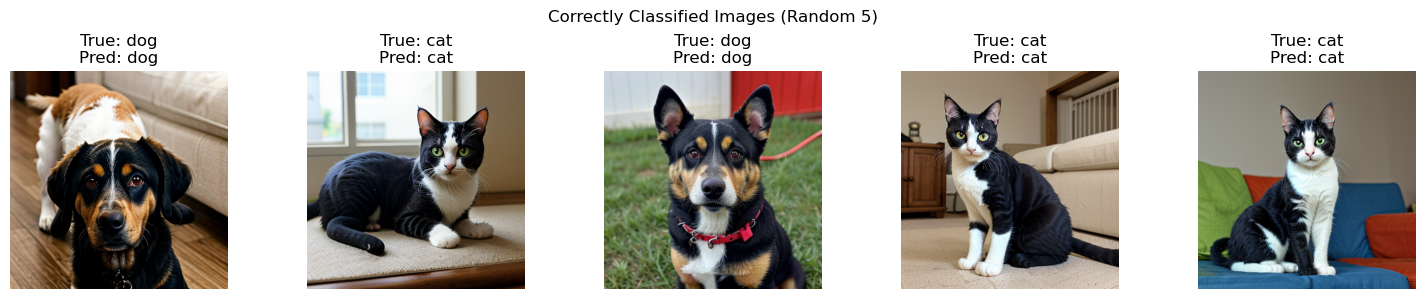

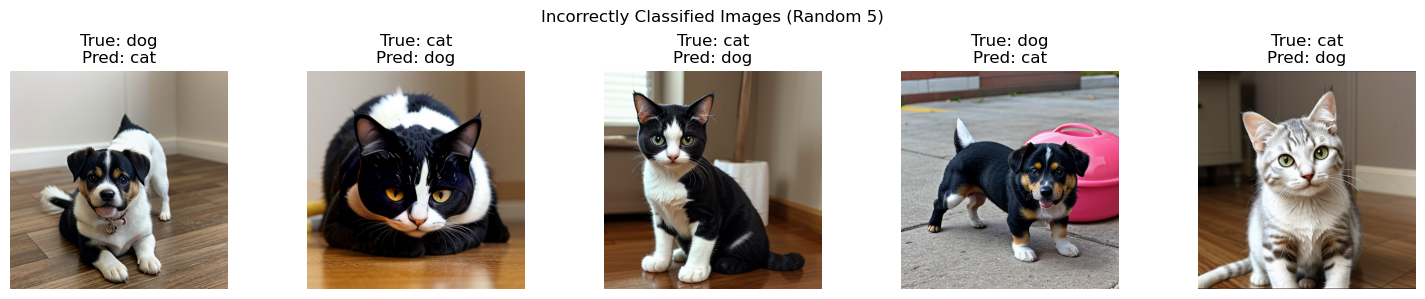

In [31]:
# Optional: Function to display images (if you want to see them directly in Python)
import matplotlib.pyplot as plt
import random

def display_images(image_list, title):
    """Display a grid of images (randomly selects 5)"""
    if not image_list:
        print(f"No images to display for {title}")
        return
    
    # Randomly select up to 5 images
    n_images = min(len(image_list), 5)
    random_selection = random.sample(image_list, n_images)
    
    fig, axes = plt.subplots(1, n_images, figsize=(15, 3))
    if n_images == 1:
        axes = [axes]
    
    for i, result in enumerate(random_selection):
        try:
            # Using plt.imread instead of mpimg.imread
            img = plt.imread(result['image_path'])
            axes[i].imshow(img)
            axes[i].set_title(f"True: {result['true_class']}\nPred: {result['pred_class']}")
            axes[i].axis('off')
        except FileNotFoundError:
            axes[i].text(0.5, 0.5, f"Image not found\n{result['filename']}.png", 
                        ha='center', va='center')
            axes[i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Ask if user wants to display images
display_images(correct_predictions, "Correctly Classified Images (Random 5)")
display_images(incorrect_predictions, "Incorrectly Classified Images (Random 5)")